# Machine Learning - Classificação 04
- KNN
- Standart Scaler

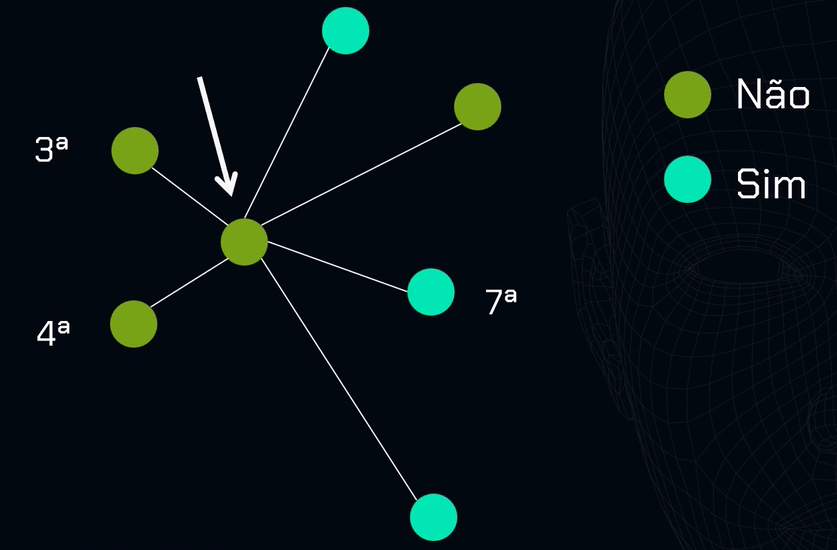

In [1]:
import pandas as pd

In [2]:
X = pd.read_csv("marketing_investimento_features.csv")
y = pd.read_csv("marketing_investimento_target.csv")

X.drop(columns=["Unnamed: 0"], inplace=True)
y.drop(columns=["Unnamed: 0"], inplace=True)

Realizando a normalização dos dados
1. Com o MinMaxScaler
2. Com o StandardScaler

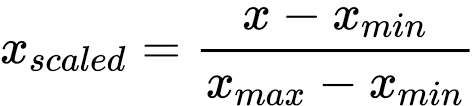

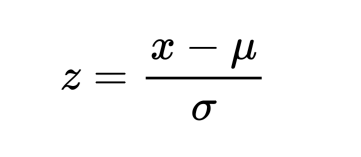

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
scaler_MMS = MinMaxScaler()
# recriando os datasets de treino
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, stratify = y, random_state = 42)

X_treino_normalizado_MSS = scaler_MMS.fit_transform(X_treino)

In [5]:
standard_scaler = StandardScaler()
# recriando os datasets de treino


X_treino_normalizado_STD = standard_scaler.fit_transform(X_treino)

In [6]:
X_treino_normalizado_MSS

array([[1.        , 0.        , 0.        , ..., 0.06256315, 0.05680174,
        0.06451613],
       [0.        , 0.        , 1.        , ..., 0.05431122, 0.08176556,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.1200741 , 0.09261939,
        0.        ],
       ...,
       [0.        , 0.        , 1.        , ..., 0.04252273, 0.0198987 ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.05090098, 0.17474674,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.05911081, 0.0723589 ,
        0.06451613]], shape=(951, 12))

In [7]:
X_treino_normalizado_STD

array([[ 0.85202865, -0.37819155, -0.6476133 , ..., -0.44834595,
        -0.5777544 ,  0.06301622],
       [-1.17366946, -0.37819155,  1.54413135, ..., -0.52656877,
        -0.38113039, -0.59553795],
       [-1.17366946, -0.37819155,  1.54413135, ...,  0.09681918,
        -0.29564168, -0.59553795],
       ...,
       [-1.17366946, -0.37819155,  1.54413135, ..., -0.63831565,
        -0.86841598, -0.59553795],
       [-1.17366946,  2.64416275, -0.6476133 , ..., -0.55889554,
         0.35122282, -0.59553795],
       [-1.17366946,  2.64416275, -0.6476133 , ..., -0.48107182,
        -0.45522059,  0.06301622]], shape=(951, 12))

In [8]:
X_treino_normalizado_MSS = pd.DataFrame(X_treino_normalizado_MSS)
X_treino_normalizado_STD = pd.DataFrame(X_treino_normalizado_STD)

Podemos analisar que as colunas booleanas não foram alteradas (valores 0 e 1 não são afetads pela fórmula)

### KNN
O algoritimo olha para os "vizinhos" mais próximos através de um calculo de distânca, e buscando esses elementos preve o valor atual.
>
Por conta de usar a distância como parâmetro de previsão, é importante que a escala das **features estejam normalizadas** (Scaler)

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn_MSS = KNeighborsClassifier()
knn_STD = KNeighborsClassifier()

In [10]:
X_teste_MSS = scaler_MMS.transform(X_teste)
X_teste_STD = standard_scaler.transform(X_teste)

In [11]:
knn_MSS.fit(X_treino_normalizado_MSS, y_treino)
knn_MSS.score(X_teste_MSS,y_teste)

/home/leo/.local/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.6971608832807571

In [12]:
knn_STD.fit(X_treino_normalizado_STD, y_treino)
knn_STD.score(X_teste_STD,y_teste)

/home/leo/.local/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.7129337539432177

Podemos observar que os dados normalizados pelo **Standard Scaler** **tiveram um desempenho melhor do que os dados treinados com o MinMaxScaler**

---
### Comparar o resultado dos modelos e exportar o modelo

- Dummy
- DecisionTree
- KNN

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier

dummy = DummyClassifier() #criando uma variavel com a classe do modelo
dummy.fit(X_treino, y_treino) # todos os modelos se treinam com fit



arvore = DecisionTreeClassifier(random_state = 5, max_depth = 5)
arvore.fit(X_treino , y_treino)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
print(f"Dummy Acuracia: {dummy.score(X_teste, y_teste)}")
print(f"Arvore Acuracia: {arvore.score(X_teste, y_teste)}")
print(f"KNN MinMaxScaler Acuracia: {knn_MSS.score(X_teste_MSS, y_teste)}")
print(f"KNN Standard Scaler Acuracia: {knn_STD.score(X_teste_STD, y_teste)}")

Dummy Acuracia: 0.6056782334384858
Arvore Acuracia: 0.7097791798107256
KNN MinMaxScaler Acuracia: 0.6971608832807571
KNN Standard Scaler Acuracia: 0.7129337539432177


O modelo vencedor (melhor acuracia) foi o **KNN com dados normalizados pelo Stardard Scaler**

Vamos salvar o nosso modelo para prever novos dados.
Como realizamos o processo de one-hot-enconconder precisamos que os novos dados também estajam neste padrão. E a mesma lógica se aplica ao Standard Scaler

In [19]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'), # não converte colunas binarias
    ['estado_civil', 'escolaridade', 'inadimplencia', 'fez_emprestimo'] # colunas de objetc
),
    remainder = 'passthrough', # este reminder manter as outras colunas
    sparse_threshold= 0 # faz com que ele mantenha as colunas com os valores originais
    )

In [20]:
import pickle

with open('one_hot_encoder.pkl', 'wb') as f:
    pickle.dump(one_hot, f)

with open('modelo_KNN_Standard_Scaler.pkl', 'wb') as f:
    pickle.dump(knn_STD, f)

### Sobre o arquivo .pickle

Assim, é possível armazenar modelos de machine learning em arquivos pickle, para que possam ser utilizados em outros programas. Ele preserva completamente o estado do objeto, incluindo todos os parâmetros e configurações. Além disso, o formato binário gerado pelo pickle é independente da plataforma, o que significa que é possível criar um arquivo em um sistema operacional e carregá-lo em outro sem problema de compatibilidade. Vale destacar que em versões diferentes do Python isto pode ser um problema. Objetos serializados em uma versão específica podem não ser carregados corretamente em outra versão. Portanto, é muito importante saber qual a versão da linguagem e das bibliotecas utilizadas no projeto para que sejam replicadas dentro do sistema em que vai ser utilizado.

O processo para utilizar o pickle envolve principalmente duas funções:

pickle.dump(objeto, arquivo): Esta função permite armazenar um objeto Python em um arquivo. O argumento objeto é o objeto que você deseja serializar, e o argumento arquivo é o objeto de arquivo onde você deseja armazenar a representação binária.
pickle.load(arquivo): Esta função permite que você desserialize (carregue) um objeto Python de um arquivo. O argumento arquivo é o arquivo de onde você deseja carregar a representação binária.
Podemos usar também a biblioteca pandas para fazer a leitura de arquivos pickle. Para isso, basta utilizar o método pd.read_pickle.